In [ ]:
import torch
from pytorch3d.io import load_objs_as_meshes
from pytorch3d.renderer import (
    look_at_view_transform, FoVPerspectiveCameras,
    PointLights, RasterizationSettings, MeshRenderer, MeshRasterizer, SoftPhongShader
)
import matplotlib.pyplot as plt

# Загрузка одного obj
mesh = load_objs_as_meshes(["data/7778_3a9748b3/assembly.obj"])

# Настройка камеры
R, T = look_at_view_transform(dist=3, elev=30, azim=45)
cameras = FoVPerspectiveCameras(R=R, T=T)

# Рендерер
renderer = MeshRenderer(
    rasterizer=MeshRasterizer(cameras=cameras, raster_settings=RasterizationSettings(image_size=512)),
    shader=SoftPhongShader(cameras=cameras, lights=PointLights(location=[[0,0,3]]))
)

# Рендер и показ
plt.imshow(renderer(mesh)[0, ..., :3].cpu().numpy())
plt.axis('off')
plt.show()

In [1]:
import torch
from pytorch3d.io import load_objs_as_meshes
from pytorch3d.renderer import (
    look_at_view_transform, FoVPerspectiveCameras,
    PointLights, RasterizationSettings, MeshRenderer, MeshRasterizer, SoftPhongShader
)
import matplotlib.pyplot as plt

In [2]:
mesh = load_objs_as_meshes(["data/7778_3a9748b3/assembly.obj"])

/Users/neonilllai/miniconda3/envs/fusion_env/lib/python3.10/site-packages/pytorch3d/io/obj_io.py:547: UserWarning: No mtl file provided
  warnings.warn("No mtl file provided")


In [4]:
mesh.faces_list

<bound method Meshes.faces_list of <pytorch3d.structures.meshes.Meshes object at 0x14348b4f0>>

In [3]:
R, T = look_at_view_transform(dist=3, elev=30, azim=45)
cameras = FoVPerspectiveCameras(R=R, T=T)

In [4]:
renderer = MeshRenderer(
    rasterizer=MeshRasterizer(cameras=cameras, raster_settings=RasterizationSettings(image_size=512)),
    shader=SoftPhongShader(cameras=cameras, lights=PointLights(location=[[0,0,3]]))
)

In [7]:
renderer

MeshRenderer(
  (rasterizer): MeshRasterizer(
    (cameras): FoVPerspectiveCameras()
  )
  (shader): SoftPhongShader(
    (lights): PointLights()
    (materials): Materials()
    (cameras): FoVPerspectiveCameras()
  )
)

In [ ]:
plt.imshow(renderer(mesh)[0, ..., :3].cpu().numpy())

In [5]:
renderer(mesh)

ValueError: Meshes does not have textures

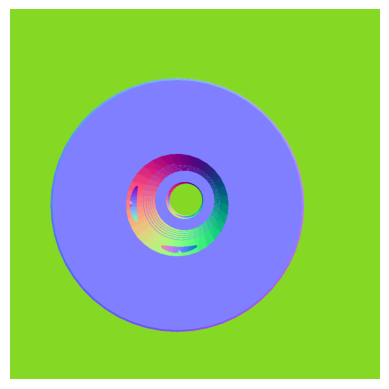

In [43]:
import torch
from pytorch3d.io import load_objs_as_meshes
from pytorch3d.renderer import (
    look_at_view_transform, FoVPerspectiveCameras,
    RasterizationSettings, MeshRenderer, MeshRasterizer
)
import matplotlib.pyplot as plt

# Загрузка меша с нормалями
mesh = load_objs_as_meshes(["data/20186_f66e4ad3/assembly.obj"], device="cpu")

# Камера
R, T = look_at_view_transform(dist=5, elev=0, azim=0)
cameras = FoVPerspectiveCameras(R=R, T=T)

# Растеризатор
rasterizer = MeshRasterizer(
    cameras=cameras,
    raster_settings=RasterizationSettings(image_size=1024)
)

# Получаем нормали для каждого пикселя
fragments = rasterizer(mesh)
face_normals = mesh.faces_normals_packed()
pixel_normals = face_normals[fragments.pix_to_face[..., 0]]

# Конвертируем из [-1,1] в [0,1] для отображения
pixel_normals = (pixel_normals + 1) / 2

# Показываем
plt.imshow(pixel_normals[0].cpu().numpy())
plt.axis('off')
plt.show()

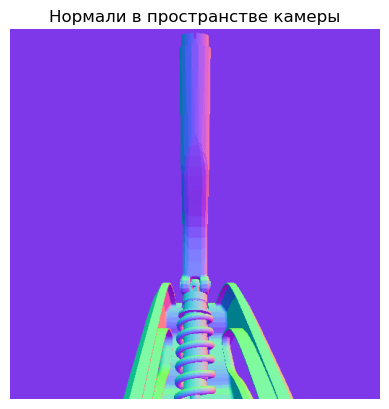

In [28]:
import torch
from pytorch3d.io import load_objs_as_meshes
from pytorch3d.renderer import (
    look_at_view_transform, FoVPerspectiveCameras,
    RasterizationSettings, MeshRasterizer
)
import matplotlib.pyplot as plt

# Загрузка
mesh = load_objs_as_meshes(["data/7778_3a9748b3/assembly.obj"], device="cpu")

# Камера
R, T = look_at_view_transform(dist=60, elev=0, azim=90)
cameras = FoVPerspectiveCameras(R=R, T=T)

# Растеризация
rasterizer = MeshRasterizer(
    cameras=cameras,
    raster_settings=RasterizationSettings(image_size=512)
)
fragments = rasterizer(mesh)

# Берем нормали граней
face_normals = mesh.faces_normals_packed()  # [F, 3]
pixel_face_idx = fragments.pix_to_face[..., 0]  # [H, W]
pixel_normals_world = face_normals[pixel_face_idx]  # [H, W, 3]

# Поворачиваем нормали в пространство камеры
# R - матрица поворота из мировых координат в координаты камеры
pixel_normals_camera = torch.matmul(pixel_normals_world, R[0].T)

# Конвертируем в [0,1] для отображения
pixel_normals_camera = (pixel_normals_camera + 1) / 2

# Показываем
plt.imshow(pixel_normals_camera[0].cpu().numpy())
plt.axis('off')
plt.title("Нормали в пространстве камеры")
plt.show()

In [32]:
fragments.pix_to_face[0, 256, 256, 0]

tensor(5045)

In [ ]:
# После загрузки mesh
verts = mesh.verts_packed()
bbox_min = verts.min(dim=0)[0]  # [x_min, y_min, z_min]
bbox_max = verts.max(dim=0)[0]  # [x_max, y_max, z_max]
center = (bbox_min + bbox_max) / 2
size = (bbox_max - bbox_min).max()  # максимальный размер

In [33]:
import math
def generate_camera_views(mesh, num_views=20):
    # Bounding box
    verts = mesh.verts_packed()
    center = (verts.min(dim=0)[0] + verts.max(dim=0)[0]) / 2
    size = (verts.max(dim=0)[0] - verts.min(dim=0)[0]).max()
    
    # Расстояние
    fov = 60
    distance = (size / 2) / math.tan(math.radians(fov/2)) * 1.2
    
    # Точки на сфере
    views = []
    for i in range(num_views):
        # Равномерно или случайно
        theta = 2 * math.pi * i / num_views  # равномерно
        # theta = random.uniform(0, 2*math.pi)  # случайно
        
        phi = math.pi/3  # фиксированная высота
        # phi = random.uniform(math.pi/6, math.pi/2)  # случайная высота
        
        x = center[0] + distance * math.sin(phi) * math.cos(theta)
        y = center[1] + distance * math.sin(phi) * math.sin(theta)
        z = center[2] + distance * math.cos(phi)
        
        views.append({
            'position': [x, y, z],
            'look_at': center.tolist(),
            'distance': distance,
            'azimuth': math.degrees(theta),
            'elevation': math.degrees(phi)
        })
    
    return views

In [34]:
mesh = load_objs_as_meshes(["data/20186_f66e4ad3/assembly.obj"], device="cpu")

/Users/neonilllai/miniconda3/envs/fusion_env/lib/python3.10/site-packages/pytorch3d/io/obj_io.py:547: UserWarning: No mtl file provided
  warnings.warn("No mtl file provided")


In [35]:
def generate_camera_views(mesh, num_views=20):
    # Bounding box
    verts = mesh.verts_packed()
    center = (verts.min(dim=0)[0] + verts.max(dim=0)[0]) / 2
    size = (verts.max(dim=0)[0] - verts.min(dim=0)[0]).max()
    
    # Расстояние
    fov = 60
    distance = (size / 2) / math.tan(math.radians(fov/2)) * 1.2
    
    # Точки на сфере
    views = []
    for i in range(num_views):
        # Равномерно или случайно
        theta = 2 * math.pi * i / num_views  # равномерно
        # theta = random.uniform(0, 2*math.pi)  # случайно
        
        phi = math.pi/3  # фиксированная высота
        # phi = random.uniform(math.pi/6, math.pi/2)  # случайная высота
        
        x = center[0] + distance * math.sin(phi) * math.cos(theta)
        y = center[1] + distance * math.sin(phi) * math.sin(theta)
        z = center[2] + distance * math.cos(phi)
        
        views.append({
            'position': [x, y, z],
            'look_at': center.tolist(),
            'distance': distance,
            'azimuth': math.degrees(theta),
            'elevation': math.degrees(phi)
        })
    
    return views

In [36]:
views = generate_camera_views(mesh, 9)

In [37]:
views

[{'position': [tensor(2.1108), tensor(-0.0873), tensor(2.5490)],
  'look_at': [-0.13919124007225037, -0.08730432391166687, 1.25],
  'distance': tensor(2.5981),
  'azimuth': 0.0,
  'elevation': 59.99999999999999},
 {'position': [tensor(1.5844), tensor(1.3590), tensor(2.5490)],
  'look_at': [-0.13919124007225037, -0.08730432391166687, 1.25],
  'distance': tensor(2.5981),
  'azimuth': 40.0,
  'elevation': 59.99999999999999},
 {'position': [tensor(0.2515), tensor(2.1285), tensor(2.5490)],
  'look_at': [-0.13919124007225037, -0.08730432391166687, 1.25],
  'distance': tensor(2.5981),
  'azimuth': 80.0,
  'elevation': 59.99999999999999},
 {'position': [tensor(-1.2642), tensor(1.8613), tensor(2.5490)],
  'look_at': [-0.13919124007225037, -0.08730432391166687, 1.25],
  'distance': tensor(2.5981),
  'azimuth': 119.99999999999999,
  'elevation': 59.99999999999999},
 {'position': [tensor(-2.2535), tensor(0.6822), tensor(2.5490)],
  'look_at': [-0.13919124007225037, -0.08730432391166687, 1.25],
  '

In [ ]:
import torch
from pytorch3d.io import load_objs_as_meshes
mesh =load_objs_as_meshes(["data/20186_f66e4ad3/assembly.obj"], device="cpu")

/Users/neonilllai/miniconda3/envs/fusion_env/lib/python3.10/site-packages/pytorch3d/io/obj_io.py:547: UserWarning: No mtl file provided
  warnings.warn("No mtl file provided")


In [22]:
verts = mesh.verts_packed()
center = verts.mean(dim=0)
radius = torch.norm(verts - center, dim=1).max().item()

In [23]:
center, radius

(tensor([ 13.2973, -25.3750,  -0.2207]), 72.62741088867188)

In [24]:
image_size = 256
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
target_fill = 0.9
n_cameras = 9

In [25]:
theta = torch.rand(1) * torch.pi
phi = 2 * torch.pi * torch.rand(1)

u = torch.tensor([
    torch.sin(theta) * torch.cos(phi),
    torch.sin(theta) * torch.sin(phi),
    torch.cos(theta)
], device=device)

In [26]:
u

tensor([-0.7479, -0.5883,  0.3074])

In [27]:
log_f_min = torch.log(torch.tensor(image_size * target_fill / 2.))
log_f_max = torch.log(torch.tensor(image_size))
log_f = log_f_min + torch.rand(1) * (log_f_max - log_f_min)
f = torch.exp(log_f).item()

In [28]:
f

218.3084716796875

In [29]:
d = (2 * f * radius) / (target_fill * image_size)
position = center - d * u

In [30]:
forward = (center - position) / d
world_up = torch.tensor([0.0, 1.0, 0.0], device=device)
right = torch.cross(world_up, forward, dim=0)
right = right / torch.norm(right)
up = torch.cross(forward, right)
rotation = torch.stack([right, up, -forward], dim=1)

In [31]:
from pytorch3d.renderer import PerspectiveCameras
camera = PerspectiveCameras(
    focal_length=torch.tensor([[f, f]], device=device),
    principal_point=torch.tensor([[0.0, 0.0]], device=device),
    R=rotation.unsqueeze(0),
    T=position.unsqueeze(0),
    device=device
    )

In [36]:
from pytorch3d.renderer import MeshRasterizer, RasterizationSettings
rasterizer = MeshRasterizer(
    cameras=camera,
    raster_settings=RasterizationSettings(image_size=256)
)

In [37]:
fragments = rasterizer(mesh)

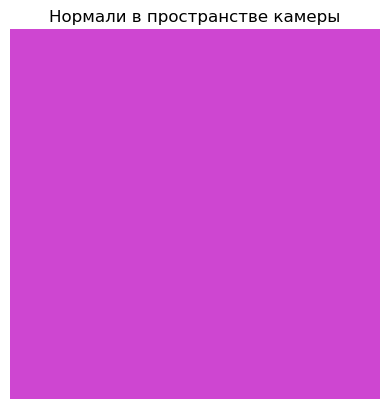

In [38]:
import matplotlib.pyplot as plt
face_normals = mesh.faces_normals_packed()  # [F, 3]
pixel_face_idx = fragments.pix_to_face[..., 0]  # [H, W]
pixel_normals_world = face_normals[pixel_face_idx]  # [H, W, 3]

# Поворачиваем нормали в пространство камеры
# R - матрица поворота из мировых координат в координаты камеры
pixel_normals_camera = torch.matmul(pixel_normals_world, rotation.unsqueeze(0).transpose(1, 2))

# Конвертируем в [0,1] для отображения
pixel_normals_camera = (pixel_normals_camera + 1) / 2

# Показываем
plt.imshow(pixel_normals_camera[0].cpu().numpy())
plt.axis('off')
plt.title("Нормали в пространстве камеры")
plt.show()

/Users/neonilllai/miniconda3/envs/fusion_env/lib/python3.10/site-packages/pytorch3d/io/obj_io.py:547: UserWarning: No mtl file provided
  warnings.warn("No mtl file provided")


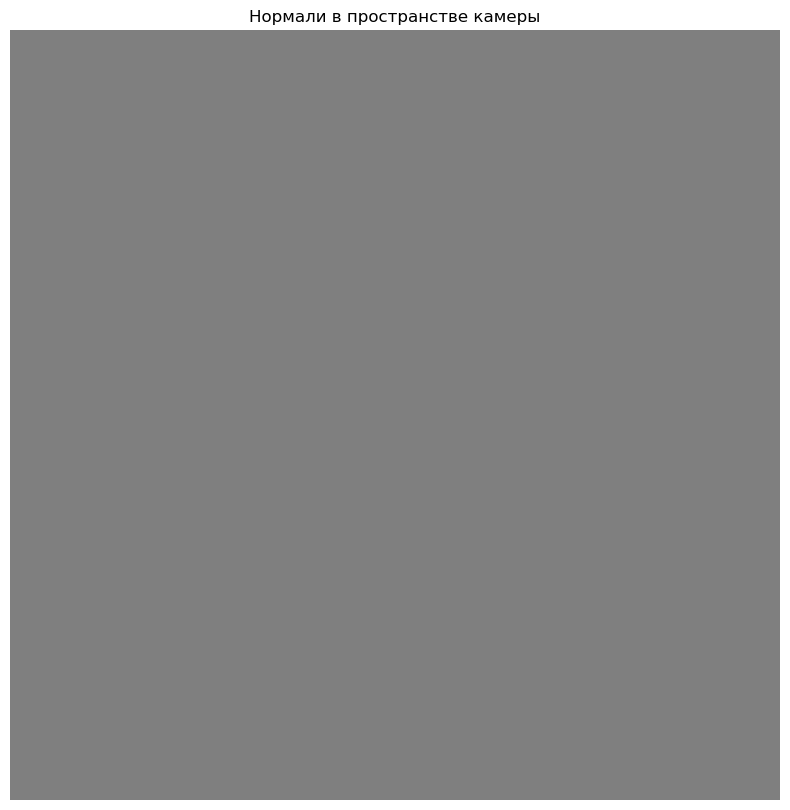

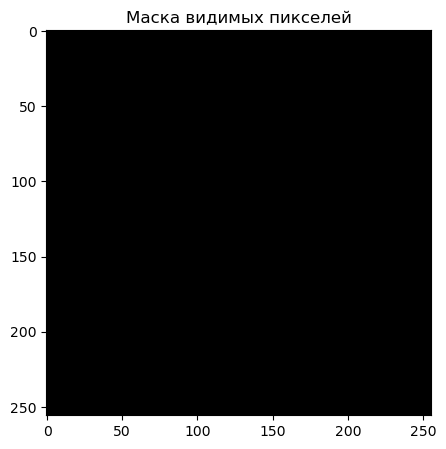

In [39]:
import torch
import matplotlib.pyplot as plt
from pytorch3d.io import load_objs_as_meshes
from pytorch3d.renderer import PerspectiveCameras, MeshRasterizer, RasterizationSettings

# ========== 1. Загрузка меша ==========
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
mesh = load_objs_as_meshes(["data/20186_f66e4ad3/assembly.obj"], device=device)

# ========== 2. Вычисление центра и радиуса ==========
verts = mesh.verts_packed()
center = verts.mean(dim=0)
radius = torch.norm(verts - center, dim=1).max().item()

# ========== 3. Параметры ==========
image_size = 256
target_fill = 0.9
n_cameras = 1  # пока одна камера

# ========== 4. Сэмплирование камеры ==========
theta = torch.rand(1, device=device) * torch.pi
phi = 2 * torch.pi * torch.rand(1, device=device)

u = torch.tensor([
    torch.sin(theta) * torch.cos(phi),
    torch.sin(theta) * torch.sin(phi),
    torch.cos(theta)
], device=device).squeeze()

log_f_min = torch.log(torch.tensor(image_size * target_fill / 2., device=device))
log_f_max = torch.log(torch.tensor(image_size, device=device))
log_f = log_f_min + torch.rand(1, device=device) * (log_f_max - log_f_min)
f = torch.exp(log_f).item()

# Расстояние и позиция
d = (2 * f * radius) / (target_fill * image_size)
position = center - d * u

# ========== 5. Матрица поворота камеры ==========
forward = (center - position) / d
world_up = torch.tensor([0.0, 1.0, 0.0], device=device)
right = torch.cross(world_up, forward)
right = right / torch.norm(right)
up = torch.cross(forward, right)

# Матрица поворота: [x_cam, y_cam, -z_cam]
rotation = torch.stack([right, up, -forward], dim=1)

# ========== 6. Создание камеры ==========
camera = PerspectiveCameras(
    focal_length=torch.tensor([[f, f]], device=device),
    principal_point=torch.tensor([[0.0, 0.0]], device=device),
    R=rotation.unsqueeze(0),
    T=position.unsqueeze(0),
    device=device
)

# ========== 7. Растеризация ==========
raster_settings = RasterizationSettings(image_size=image_size, faces_per_pixel=1)
rasterizer = MeshRasterizer(cameras=camera, raster_settings=raster_settings)
fragments = rasterizer(mesh)

# ========== 8. Получение нормалей ==========
# Получаем индексы граней для каждого пикселя
pix_to_face = fragments.pix_to_face  # (1, H, W, 1)
pixel_face_idx = pix_to_face[0, ..., 0]  # (H, W)

# Получаем нормали граней
face_normals = mesh.faces_normals_packed()  # (F, 3)

# ВАЖНО: маскируем пиксели без попаданий
valid_pixels = pixel_face_idx >= 0  # (H, W)

# Создаем тензор для нормалей
pixel_normals_world = torch.zeros((image_size, image_size, 3), device=device)
pixel_normals_world[valid_pixels] = face_normals[pixel_face_idx[valid_pixels]]

# ========== 9. Преобразование нормалей в пространство камеры ==========
# Для нормалей: n_cam = R @ n_world (без транспонирования)
# R - матрица поворота из мировых координат в координаты камеры
pixel_normals_camera = torch.matmul(pixel_normals_world, rotation.T)

# Нормализуем (на всякий случай)
pixel_normals_camera = pixel_normals_camera / torch.norm(pixel_normals_camera, dim=2, keepdim=True).clamp(min=1e-6)

# ========== 10. Визуализация ==========
# Конвертируем из диапазона [-1, 1] в [0, 1] для RGB
pixel_normals_rgb = (pixel_normals_camera + 1) / 2

plt.figure(figsize=(10, 10))
plt.imshow(pixel_normals_rgb.cpu().numpy())
plt.axis('off')
plt.title("Нормали в пространстве камеры")
plt.show()

# Дополнительно: показываем маску, чтобы убедиться, что объект виден
plt.figure(figsize=(5, 5))
plt.imshow(valid_pixels.cpu().numpy(), cmap='gray')
plt.title("Маска видимых пикселей")
plt.show()

=== ПАРАМЕТРЫ КАМЕРЫ ===
Центр объекта: tensor([-0.2845, -0.2213,  1.2289])
Радиус: 1.737
Фокус f: 153.6
Расстояние d: 2.316
Позиция камеры: tensor([ 1.6325, -0.5081, -0.0383])
Направление взгляда u: tensor([-0.8278,  0.1239,  0.5472])
Forward (центр - позиция)/d: tensor([-0.8278,  0.1239,  0.5472])
Расстояние от камеры до центра: 2.316
Ожидаемое расстояние: 2.316
=== ДИАГНОСТИКА ===
Количество граней: 9506
Форма face_normals: torch.Size([9506, 3])
Уникальные индексы граней в pix_to_face: tensor([-1])
Количество валидных пикселей: 0
Процент заполнения: 0.0%
Нормали граней (первые 3):
tensor([[-0.0152, -0.6287,  0.7775],
        [-0.0435, -0.6775,  0.7343],
        [-0.0536, -0.7164,  0.6957]])
normals_world - min: 0.000, max: 0.000
normals_camera - min: 0.000, max: 0.000


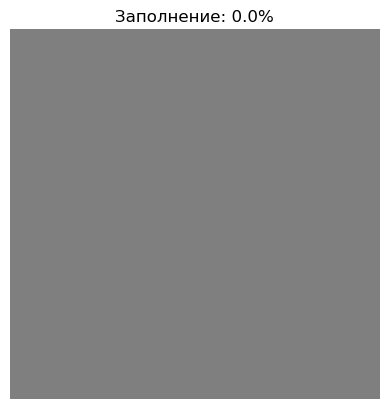

In [44]:
import torch
import matplotlib.pyplot as plt
from pytorch3d.io import load_objs_as_meshes
from pytorch3d.renderer import PerspectiveCameras, MeshRasterizer, RasterizationSettings

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Загрузка
mesh = load_objs_as_meshes(["data/20186_f66e4ad3/assembly.obj"], device=device)

# Центр и радиус
verts = mesh.verts_packed()
center = verts.mean(dim=0)
radius = torch.norm(verts - center, dim=1).max().item()

# Параметры
image_size = 256
target_fill = 0.9
f = image_size * 0.6  # фиксированный фокус для простоты

# Случайное направление
theta = torch.rand(1, device=device) * torch.pi
phi = 2 * torch.pi * torch.rand(1, device=device)
u = torch.tensor([
    torch.sin(theta) * torch.cos(phi),
    torch.sin(theta) * torch.sin(phi),
    torch.cos(theta)
], device=device).squeeze()

# Позиция
d = (2 * f * radius) / (target_fill * image_size)
position = center - d * u

# Поворот
forward = (center - position) / d
world_up = torch.tensor([0.0, 1.0, 0.0], device=device)
right = torch.cross(world_up, forward)
right = right / torch.norm(right)
up = torch.cross(forward, right)
rotation = torch.stack([right, up, -forward], dim=1)
print("=== ПАРАМЕТРЫ КАМЕРЫ ===")
print(f"Центр объекта: {center}")
print(f"Радиус: {radius:.3f}")
print(f"Фокус f: {f:.1f}")
print(f"Расстояние d: {d:.3f}")
print(f"Позиция камеры: {position}")
print(f"Направление взгляда u: {u}")
print(f"Forward (центр - позиция)/d: {(center - position)/d}")

# Проверяем, где находится камера относительно объекта
print(f"Расстояние от камеры до центра: {torch.norm(position - center):.3f}")
print(f"Ожидаемое расстояние: {d:.3f}")
# Камера
camera = PerspectiveCameras(
    focal_length=torch.tensor([[f, f]], device=device),
    principal_point=torch.tensor([[0.0, 0.0]], device=device),
    R=rotation.unsqueeze(0),
    T=position.unsqueeze(0),
    device=device
)

# Растеризация
rasterizer = MeshRasterizer(
    cameras=camera,
    raster_settings=RasterizationSettings(image_size=image_size, faces_per_pixel=1)
)
fragments = rasterizer(mesh)



# Получение нормалей
pix_to_face = fragments.pix_to_face[0, ..., 0]  # (H, W)
valid = pix_to_face >= 0

face_normals = mesh.faces_normals_packed()
normals_world = torch.zeros((image_size, image_size, 3), device=device)
normals_world[valid] = face_normals[pix_to_face[valid]]

# Преобразование в пространство камеры
normals_camera = torch.matmul(normals_world, rotation.T)
normals_camera = normals_camera / torch.norm(normals_camera, dim=2, keepdim=True).clamp(min=1e-6)
print("=== ДИАГНОСТИКА ===")
print(f"Количество граней: {mesh.faces_packed().shape[0]}")
print(f"Форма face_normals: {face_normals.shape}")
print(f"Уникальные индексы граней в pix_to_face: {torch.unique(pix_to_face)}")
print(f"Количество валидных пикселей: {valid.sum().item()}")
print(f"Процент заполнения: {valid.float().mean().item()*100:.1f}%")
print(f"Нормали граней (первые 3):\n{face_normals[:3]}")
print(f"normals_world - min: {normals_world.min():.3f}, max: {normals_world.max():.3f}")
print(f"normals_camera - min: {normals_camera.min():.3f}, max: {normals_camera.max():.3f}")
# Визуализация
normals_rgb = (normals_camera + 1) / 2
plt.imshow(normals_rgb.cpu().numpy())
plt.axis('off')
plt.title(f"Заполнение: {(valid.float().mean().item()*100):.1f}%")
plt.show()

In [45]:
import torch
import matplotlib.pyplot as plt
from pytorch3d.io import load_objs_as_meshes
from pytorch3d.renderer import PerspectiveCameras, MeshRasterizer, RasterizationSettings

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Загрузка
mesh = load_objs_as_meshes(["data/20186_f66e4ad3/assembly.obj"], device=device)

# Центр и радиус
verts = mesh.verts_packed()
center = verts.mean(dim=0)
radius = torch.norm(verts - center, dim=1).max().item()

print(f"Центр: {center}")
print(f"Радиус: {radius:.3f}")

# Параметры
image_size = 512
target_fill = 0.8
f = image_size * 0.5  # фокусное расстояние

# Случайное направление
theta = torch.rand(1, device=device) * torch.pi
phi = 2 * torch.pi * torch.rand(1, device=device)
u = torch.tensor([
    torch.sin(theta) * torch.cos(phi),
    torch.sin(theta) * torch.sin(phi),
    torch.cos(theta)
], device=device).squeeze()

# Расстояние - используем эмпирическое правило
d = radius * 3.5
position = center - d * u
print(f"Расстояние: {d:.3f}")

# Поворот
forward = (center - position) / d
world_up = torch.tensor([0.0, 1.0, 0.0], device=device)

if torch.abs(torch.dot(forward, world_up)) > 0.999:
    world_up = torch.tensor([0.0, 0.0, 1.0], device=device)

right = torch.cross(world_up, forward)
right = right / torch.norm(right)
up = torch.cross(forward, right)
rotation = torch.stack([right, up, -forward], dim=1)

# Камера с in_ndc=False
camera = PerspectiveCameras(
    focal_length=torch.tensor([[f, f]], device=device),
    principal_point=torch.tensor([[0.0, 0.0]], device=device),
    R=rotation.unsqueeze(0),
    T=position.unsqueeze(0),
    in_ndc=False,  # КЛЮЧЕВОЙ ПАРАМЕТР
    image_size=((image_size, image_size),),
    device=device
)

# Растеризация
rasterizer = MeshRasterizer(
    cameras=camera,
    raster_settings=RasterizationSettings(image_size=image_size, faces_per_pixel=1)
)
fragments = rasterizer(mesh)

# Проверка
pix_to_face = fragments.pix_to_face[0, ..., 0]
valid = pix_to_face >= 0
fill = valid.float().mean().item() * 100
print(f"Заполнение: {fill:.1f}%")

if fill > 0:
    face_normals = mesh.faces_normals_packed()
    H, W = pix_to_face.shape
    normals_world = torch.zeros((H, W, 3), device=device)
    normals_world[valid] = face_normals[pix_to_face[valid]]
    
    normals_camera = torch.matmul(normals_world, rotation.T)
    norm = torch.norm(normals_camera, dim=2, keepdim=True)
    normals_camera = normals_camera / norm.clamp(min=1e-6)
    
    normals_rgb = (normals_camera + 1) / 2
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(normals_rgb.cpu().numpy())
    plt.axis('off')
    plt.title(f"Нормали ({fill:.1f}%)")
    
    plt.subplot(1, 2, 2)
    plt.imshow(valid.cpu().numpy(), cmap='gray')
    plt.axis('off')
    plt.title("Маска")
    plt.show()
else:
    print("Объект всё ещё не виден")
    print("Проверьте, что OBJ файл загружен правильно")
    print(f"Координаты вершин: min={verts.min(dim=0)[0]}, max={verts.max(dim=0)[0]}")

Центр: tensor([-0.2845, -0.2213,  1.2289])
Радиус: 1.737
Расстояние: 6.079
Заполнение: 0.0%
Объект всё ещё не виден
Проверьте, что OBJ файл загружен правильно
Координаты вершин: min=tensor([-1.1400e+00, -1.0881e+00, -1.1369e-12]), max=tensor([0.8616, 0.9135, 2.5000])


Центр: tensor([ 13.2973, -25.3750,  -0.2207])
Радиус: 72.627
Базовое расстояние для заполнения 80%: 163.124


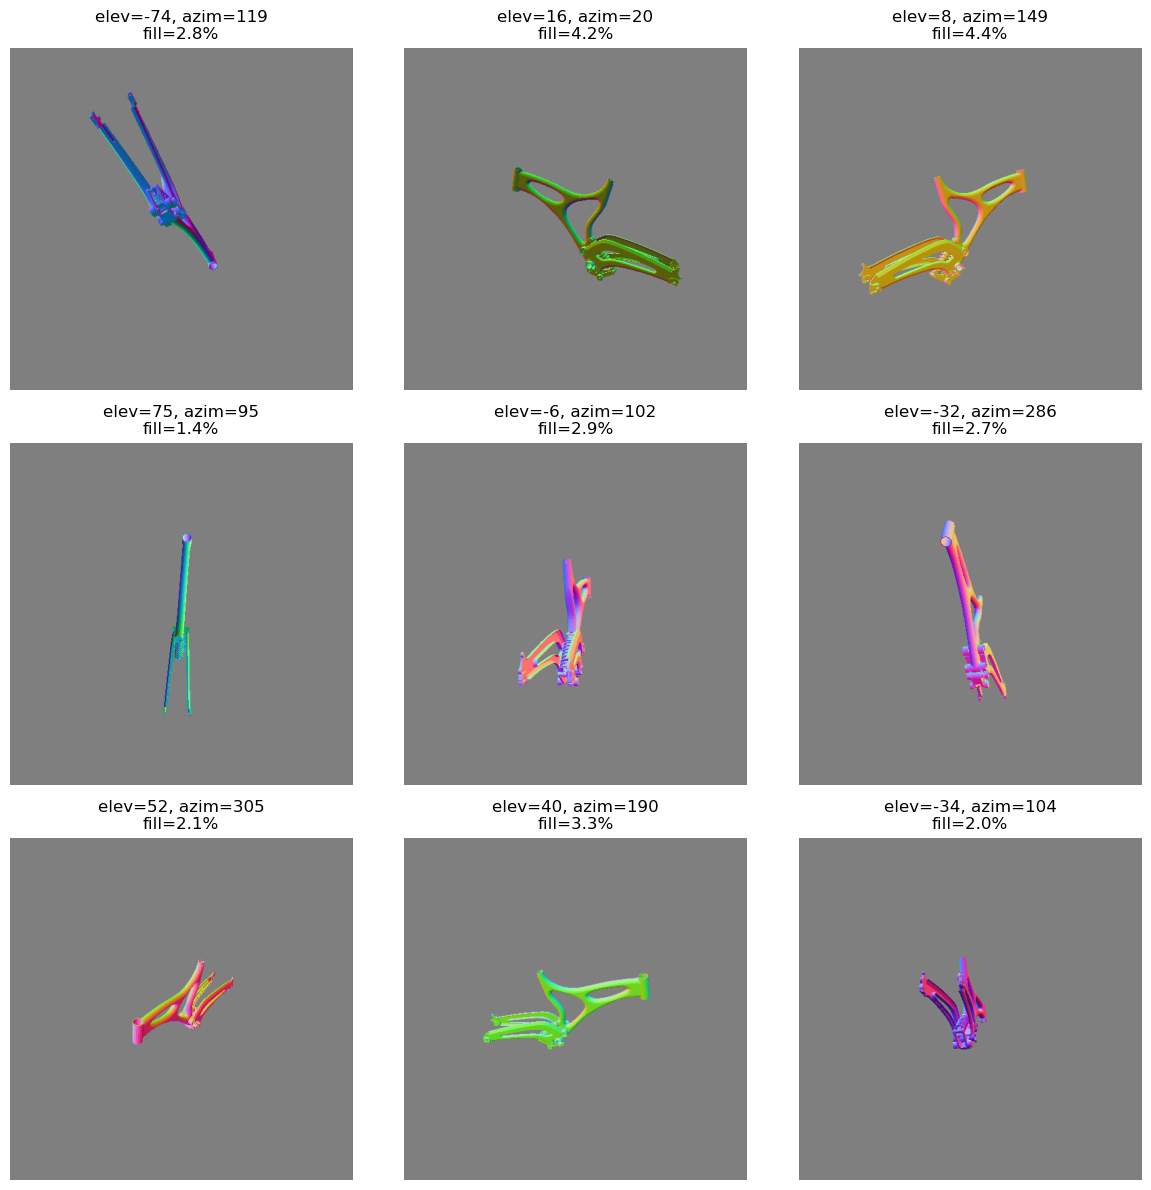

In [ ]:
import torch
import matplotlib.pyplot as plt
from pytorch3d.io import load_objs_as_meshes
from pytorch3d.renderer import (
    look_at_view_transform, FoVPerspectiveCameras,
    RasterizationSettings, MeshRasterizer
)
import numpy as np

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Загрузка
mesh = load_objs_as_meshes(["data/7778_3a9748b3/assembly.obj"], device=device)

# Центр и радиус
verts = mesh.verts_packed()
center = verts.mean(dim=0)
radius = torch.norm(verts - center, dim=1).max().item()
print(f"Центр: {center}")
print(f"Радиус: {radius:.3f}")

# Параметры
image_size = 512
target_fill = 0.9

# ========== ФУНКЦИЯ СЭМПЛИРОВАНИЯ ==========
def sample_cameras_fov(
    center: torch.Tensor,
    radius: float,
    image_size: int,
    n_cameras: int,
    target_fill: float = 0.8,
    device: torch.device = torch.device("cpu")
):
    """
    Сэмплирует камеры на сфере с расстоянием, дающим target_fill заполнение
    """
    cameras = []
    
    # Фиксированное поле зрения (по умолчанию 60°)
    fov_deg = 60
    fov_rad = fov_deg * np.pi / 180
    
    # Расстояние для target_fill заполнения
    # Формула: angular_size = target_fill * fov
    #          distance = radius / tan(angular_size/2)
    angular_size = target_fill * fov_rad
    distance = radius / np.tan(angular_size / 2)
    
    print(f"Базовое расстояние для заполнения {target_fill*100:.0f}%: {distance:.3f}")
    
    for i in range(n_cameras):
        # Случайное направление на сфере (равномерное)
        theta = np.arccos(1 - 2 * np.random.rand())
        phi = 2 * np.pi * np.random.rand()
        
        # Преобразуем в углы для look_at_view_transform
        # theta = 0 -> elev=90 (сверху), theta = 90 -> elev=0 (сбоку)
        elev = 90 - theta * 180 / np.pi
        azim = phi * 180 / np.pi
        
        # Случайное расстояние (немного варьируем вокруг оптимального)
        dist = distance * (0.9 + 0.2 * np.random.rand())
        
        # Создаем камеру
        R, T = look_at_view_transform(dist=dist, elev=elev, azim=azim)
        camera = FoVPerspectiveCameras(
            R=R, T=T, 
            fov=fov_deg,
            device=device
        )
        
        cameras.append({
            'camera': camera,
            'R': R,
            'T': T,
            'dist': dist,
            'elev': elev,
            'azim': azim
        })
    
    return cameras

# ========== ФУНКЦИЯ РЕНДЕРИНГА НОРМАЛЕЙ ==========
def render_normals(mesh, camera, image_size=512):
    """Рендерит нормали в пространстве камеры"""
    rasterizer = MeshRasterizer(
        cameras=camera,
        raster_settings=RasterizationSettings(image_size=image_size, faces_per_pixel=1)
    )
    fragments = rasterizer(mesh)
    
    pix_to_face = fragments.pix_to_face[0, ..., 0]
    valid = pix_to_face >= 0
    
    if valid.sum() == 0:
        return None, None, 0
    
    face_normals = mesh.faces_normals_packed()
    H, W = pix_to_face.shape
    normals_world = torch.zeros((H, W, 3), device=mesh.device)
    normals_world[valid] = face_normals[pix_to_face[valid]]
    
    # Преобразование в пространство камеры
    R_cam = camera.R[0]
    normals_camera = torch.matmul(normals_world, R_cam.T)
    
    # Нормализация
    norm = torch.norm(normals_camera, dim=2, keepdim=True)
    normals_camera = normals_camera / norm.clamp(min=1e-6)
    
    fill = valid.float().mean().item() * 100
    
    return normals_camera, valid, fill

# ========== ГЕНЕРАЦИЯ И ВИЗУАЛИЗАЦИЯ ==========
n_cameras = 9
cameras = sample_cameras_fov(center, radius, image_size, n_cameras, target_fill=0.8, device=device)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for idx, cam_data in enumerate(cameras):
    normals, valid, fill = render_normals(mesh, cam_data['camera'], image_size)
    
    if normals is not None:
        normals_rgb = (normals + 1) / 2
        axes[idx].imshow(normals_rgb.cpu().numpy())
        axes[idx].set_title(f"elev={cam_data['elev']:.0f}, azim={cam_data['azim']:.0f}\nfill={fill:.1f}%")
    else:
        axes[idx].text(0.5, 0.5, "No object", ha='center', va='center')
        axes[idx].set_title(f"elev={cam_data['elev']:.0f}, azim={cam_data['azim']:.0f}")
    
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Загрузка
mesh = load_objs_as_meshes(["data/20818_098cad7c/assembly.obj"], device=device)

# Центр и радиус
verts = mesh.verts_packed()
center = verts.mean(dim=0)
radius = torch.norm(verts - center, dim=1).max().item()
print(f"Центр: {center}")
print(f"Радиус: {radius:.3f}")

# Параметры
image_size = 1024
target_fill = 0.95

Центр: tensor([0.9551, 0.5902, 5.6731])
Радиус: 11.823


/Users/neonilllai/miniconda3/envs/fusion_env/lib/python3.10/site-packages/pytorch3d/io/obj_io.py:547: UserWarning: No mtl file provided
  warnings.warn("No mtl file provided")


Базовое расстояние для заполнения 80%: 23.172


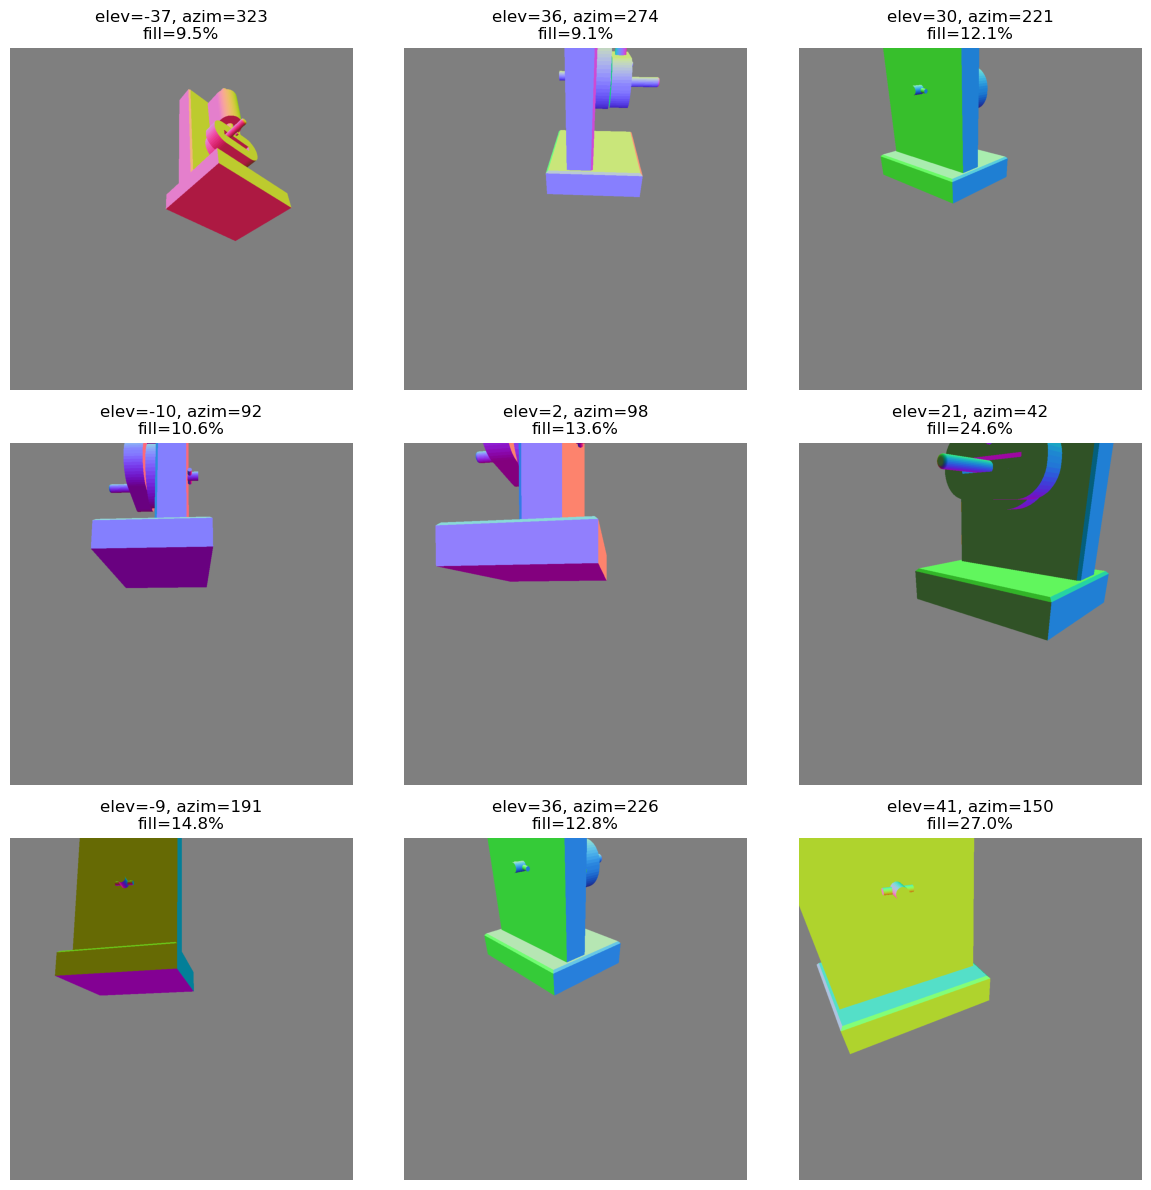

In [54]:
n_cameras = 9
cameras = sample_cameras_fov(center, radius, image_size, n_cameras, target_fill=0.8, device=device)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for idx, cam_data in enumerate(cameras):
    normals, valid, fill = render_normals(mesh, cam_data['camera'], image_size)
    
    if normals is not None:
        normals_rgb = (normals + 1) / 2
        axes[idx].imshow(normals_rgb.cpu().numpy())
        axes[idx].set_title(f"elev={cam_data['elev']:.0f}, azim={cam_data['azim']:.0f}\nfill={fill:.1f}%")
    else:
        axes[idx].text(0.5, 0.5, "No object", ha='center', va='center')
        axes[idx].set_title(f"elev={cam_data['elev']:.0f}, azim={cam_data['azim']:.0f}")
    
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pytorch3d.io import load_objs_as_meshes
from pytorch3d.renderer import (
    look_at_view_transform, FoVPerspectiveCameras,
    RasterizationSettings, MeshRasterizer
)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Загрузка
mesh = load_objs_as_meshes(["assembly.obj"], device=device)

# Камера
dist = 100
elev = 30
azim = 45
R, T = look_at_view_transform(dist=dist, elev=elev, azim=azim)
camera = FoVPerspectiveCameras(R=R, T=T, znear=0.1, zfar=200.0, device=device)

# Растеризация
rasterizer = MeshRasterizer(
    cameras=camera,
    raster_settings=RasterizationSettings(image_size=512, faces_per_pixel=1)
)
fragments = rasterizer(mesh)

# ========== ПОЛУЧЕНИЕ ГЛУБИНЫ ==========
# 1. NDC глубина (из fragments)
depth_ndc = fragments.zbuf[0, ..., 0]  # (H, W)
valid = fragments.pix_to_face[0, ..., 0] >= 0

# 2. Преобразование в мировое расстояние
znear = camera.znear.item()
zfar = camera.zfar.item()

depth_world = torch.zeros_like(depth_ndc)
depth_world[valid] = 2 * znear * zfar / (zfar + znear - depth_ndc[valid] * (zfar - znear))

# ========== ВИЗУАЛИЗАЦИЯ ==========
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Нормали
face_normals = mesh.faces_normals_packed()
normals = torch.zeros((512, 512, 3), device=device)
normals[valid] = face_normals[fragments.pix_to_face[0, ..., 0][valid]]
normals_rgb = (normals + 1) / 2

axes[0].imshow(normals_rgb.cpu().numpy())
axes[0].set_title("Нормали")
axes[0].axis('off')

# Глубина NDC
axes[1].imshow(depth_ndc.cpu().numpy(), cmap='plasma')
axes[1].set_title(f"Глубина NDC\n[{-1:.1f} .. {1:.1f}]")
axes[1].axis('off')

# Глубина в мировых координатах
depth_viz = depth_world.cpu().numpy()
depth_viz[~valid.cpu().numpy()] = np.nan
im = axes[2].imshow(depth_viz, cmap='plasma')
axes[2].set_title(f"Расстояние от камеры\n[{depth_world[valid].min():.1f} .. {depth_world[valid].max():.1f}]")
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print(f"Минимальная глубина: {depth_world[valid].min():.2f}")
print(f"Максимальная глубина: {depth_world[valid].max():.2f}")

In [55]:
def render_depths(mesh, camera, image_size=512):
    """Рендерит нормали в пространстве камеры"""
    rasterizer = MeshRasterizer(
        cameras=camera,
        raster_settings=RasterizationSettings(image_size=image_size, faces_per_pixel=1)
    )
    fragments = rasterizer(mesh)
    
    pix_to_face = fragments.pix_to_face[0, ..., 0]
    valid = pix_to_face >= 0
    
    if valid.sum() == 0:
        return None, None, 0
    depth_ndc = fragments.zbuf[0, ..., 0]
    
    fill = valid.float().mean().item() * 100
    
    return depth_ndc, valid, fill

Базовое расстояние для заполнения 80%: 26.555


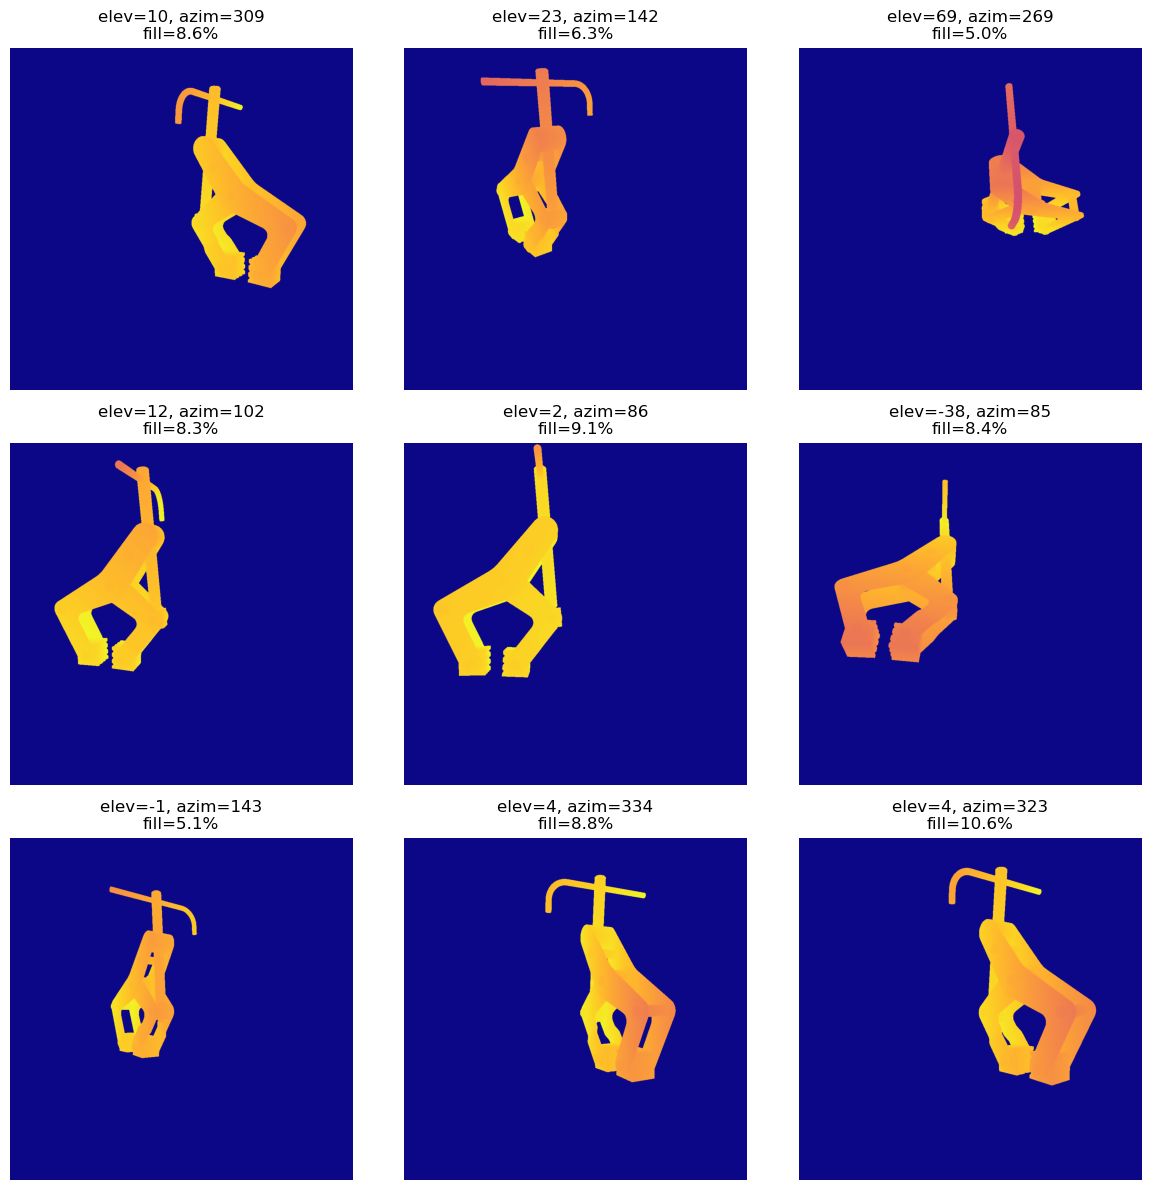

In [59]:
n_cameras = 9
cameras = sample_cameras_fov(center, radius, image_size, n_cameras, target_fill=0.8, device=device)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for idx, cam_data in enumerate(cameras):
    depths, valid, fill = render_depths(mesh, cam_data['camera'], image_size)
    
    if depths is not None:
        axes[idx].imshow(depths.cpu().numpy(), cmap='plasma')
        axes[idx].set_title(f"elev={cam_data['elev']:.0f}, azim={cam_data['azim']:.0f}\nfill={fill:.1f}%")
    else:
        axes[idx].text(0.5, 0.5, "No object", ha='center', va='center')
        axes[idx].set_title(f"elev={cam_data['elev']:.0f}, azim={cam_data['azim']:.0f}")
    
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [61]:
from pathlib import Path
data_path = 'data'
data_path = Path(data_path)
results = [folder for folder in data_path.iterdir() if folder.is_dir()]
results

[PosixPath('data/21448_5646a1b6'),
 PosixPath('data/22312_3f366a4a'),
 PosixPath('data/20756_75f43564'),
 PosixPath('data/21708_e61bd657'),
 PosixPath('data/23311_ad36a9ec'),
 PosixPath('data/22680_1f4026f6'),
 PosixPath('data/21265_7329c813'),
 PosixPath('data/22832_731d3b9f'),
 PosixPath('data/23476_705b76d1'),
 PosixPath('data/22131_6b4b60f8'),
 PosixPath('data/20994_9c88b1ba'),
 PosixPath('data/22026_62afa265'),
 PosixPath('data/22021_520ec8c3'),
 PosixPath('data/20351_dc6e4e1e'),
 PosixPath('data/22218_2f85f6ae'),
 PosixPath('data/21810_718ae2fe'),
 PosixPath('data/20215_e2eb3082'),
 PosixPath('data/22561_067b78ae'),
 PosixPath('data/21421_fb12b69b'),
 PosixPath('data/22082_39503fa6'),
 PosixPath('data/23308_245d257c'),
 PosixPath('data/22844_9b75b8e0'),
 PosixPath('data/20408_b4fda9eb'),
 PosixPath('data/21326_ab4d6c43'),
 PosixPath('data/22211_b1ee53f0'),
 PosixPath('data/23211_3aac9c7e'),
 PosixPath('data/20676_9715ec9c'),
 PosixPath('data/20220_3de82b2a'),
 PosixPath('data/227

In [65]:
str(data_path)

'data'

In [67]:
for i in range(len(results)):
    if str(results[i]) == 'data/7778_3a9748b3':
        print('find', i)

find 430


In [ ]:
for i in range(len(results)):
    assembly_file = results[i] / 'assembly.json'
    

PosixPath('data/20488_589ac9c0')

In [70]:
import json
assembly_file = results[430] / 'assembly.json'
with open(assembly_file, 'r') as f:
        data = json.load(f)

In [71]:
data

{'tree': {'root': {'72780126-0600-11ec-85f1-020dc2b44123': {},
   '728631ec-0600-11ec-9fb6-020dc2b44123': {},
   '72b16090-0600-11ec-bcca-020dc2b44123': {},
   '72b27200-0600-11ec-91a2-020dc2b44123': {},
   '72b2c024-0600-11ec-99ec-020dc2b44123': {},
   '72b35c70-0600-11ec-91b4-020dc2b44123': {},
   '72b3d194-0600-11ec-8193-020dc2b44123': {},
   '72b50a12-0600-11ec-b389-020dc2b44123': {},
   '72b55834-0600-11ec-a2f3-020dc2b44123': {},
   '72b5cd5e-0600-11ec-a395-020dc2b44123': {},
   '72b690ae-0600-11ec-bb4d-020dc2b44123': {},
   '72b70606-0600-11ec-8e72-020dc2b44123': {},
   '72b7f058-0600-11ec-adc2-020dc2b44123': {},
   '72b88c80-0600-11ec-876f-020dc2b44123': {},
   '72b94fd0-0600-11ec-b510-020dc2b44123': {},
   '72b9ec12-0600-11ec-a339-020dc2b44123': {},
   '72ba884a-0600-11ec-8d9e-020dc2b44123': {},
   '72bb4b9a-0600-11ec-9bca-020dc2b44123': {'72bc8422-0600-11ec-b6b3-020dc2b44123': {},
    '72bd6e80-0600-11ec-93b2-020dc2b44123': {},
    '72be58da-0600-11ec-b8de-020dc2b44123': {'72b

In [72]:
data['root']

{'component': '7277da10-0600-11ec-a7a7-020dc2b44123'}

In [ ]:
count = 0
for i in range(len(results)):
    assembly_file = results[i] / 'assembly.json'
    with open(assembly_file, 'r') as f:
        data = json.load(f)
    root_companent = data['root']['component']
    if data['root'].get('bodies', 0) == 0:
        len(data['components'][root_companent]['bodies'])
count

521

In [74]:
len(results)

751

In [78]:
data['root'].get('component', '0')

'bffed6e3-0595-11ec-93d4-06368d9f66a5'

In [79]:
d = {1 : 4}
d.get(2, '0')

'0'